In [ ]:
import numpy as np
import cv2

# Carga y unificación de los datasets de Sign Language Digits
try:
    # Carga del primer conjunto de datos
    X1 = np.load('X.npy')
    Y1 = np.load('Y.npy')
    
    # Carga del segundo conjunto de datos
    X2 = np.load('X2.npy') 
    Y2 = np.load('Y2.npy')

    # 1. Reordenar SOLO el Dataset 1 para alinear sus columnas al orden numérico estándar (0-9)
    orden_correcto = [1, 4, 8, 7, 6, 9, 3, 2, 5, 0]
    Y1 = Y1[:, orden_correcto]
    
    # 2. Convertir Dataset 2 a One-Hot
    Y2_one_hot = np.eye(10)[Y2]

   
    def quitar_fondo(img_float01):
        img_u8 = (img_float01 * 255).astype('uint8')
        img_blur = cv2.GaussianBlur(img_u8, (7, 7), 0)
        _, mascara = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        img_filtrada = cv2.bitwise_and(img_u8, img_u8, mask=mascara)
        return img_filtrada.astype('float32')

    X1_sin_fondo = np.array([quitar_fondo(img) for img in X1])
    
    
    # 3. Combinación de ambos datasets (ahora usando X1_sin_fondo en vez de X1)
    X = np.concatenate((X1_sin_fondo, X2), axis=0)
    Y = np.concatenate((Y1, Y2_one_hot), axis=0)
    
    print("=== PROCESO DE CARGA DE DATASETS COMPLETADO ===")
    print(f"-> Dataset 1 alineado correctamente al orden 0-9 con {X1.shape[0]} muestras.")
    print(f"-> Dataset 1 procesado para quitar fondo (mismo estilo que Dataset 2).")
    print(f"-> Dataset 2 mapeado directo al orden 0-9 con {X2.shape[0]} muestras.")
    print(f"-> Fusión exitosa: Las señas de los dígitos coinciden perfectamente. Total: {X.shape[0]} imágenes.")

except FileNotFoundError:
    print("Error de carga: Verifique los nombres de los archivos .npy en el directorio.")
except ValueError as e:
    print(f"Error de compatibilidad geométrica: {e}")

=== PROCESO DE CARGA DE DATASETS COMPLETADO ===
-> Dataset 1 alineado correctamente al orden 0-9 con 2062 muestras.
-> Dataset 1 procesado para quitar fondo (mismo estilo que Dataset 2).
-> Dataset 2 mapeado directo al orden 0-9 con 5000 muestras.
-> Fusión exitosa: Las señas de los dígitos coinciden perfectamente. Total: 7062 imágenes.


In [2]:
# 2. Análisis de las dimensiones
print(f"Total de imágenes: {X.shape[0]}")
print(f"Resolución de cada imagen: {X.shape[1]}x{X.shape[2]} píxeles")
print(f"Formato de la matriz de imágenes (X): {X.shape}")
print(f"Formato de la matriz de etiquetas (Y): {Y.shape}")

Total de imágenes: 7062
Resolución de cada imagen: 64x64 píxeles
Formato de la matriz de imágenes (X): (7062, 64, 64)
Formato de la matriz de etiquetas (Y): (7062, 10)


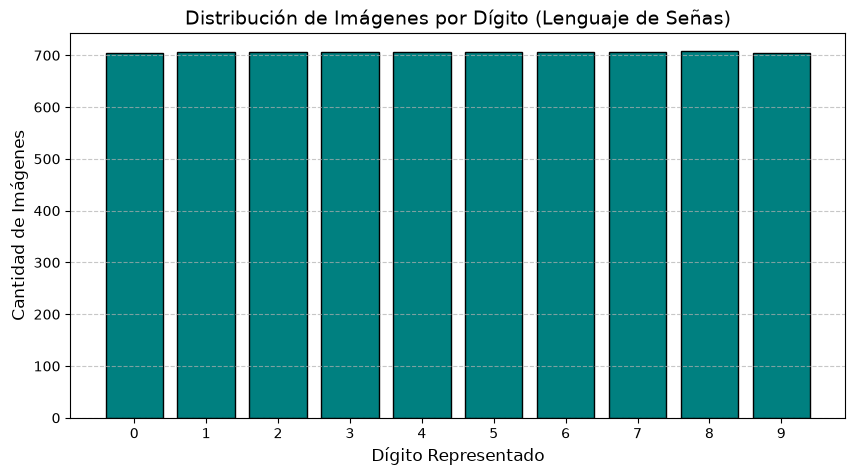

In [3]:
import matplotlib.pyplot as plt# 3. Gráfico de distribución de clases
# Convertimos las etiquetas One-Hot de vuelta a números enteros (0-9) para contarlas
labels = np.argmax(Y, axis=1)
unique_classes, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(unique_classes, counts, color='teal', edgecolor='black')
plt.title("Distribución de Imágenes por Dígito (Lenguaje de Señas)", fontsize=14)
plt.xlabel("Dígito Representado", fontsize=12)
plt.ylabel("Cantidad de Imágenes", fontsize=12)
plt.xticks(unique_classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

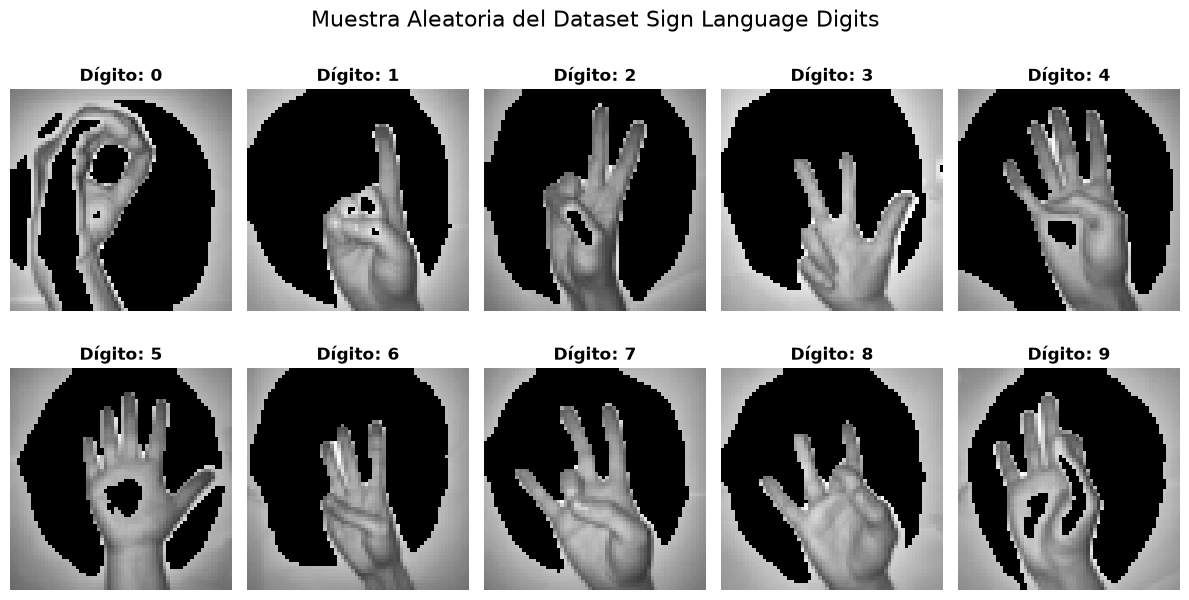

In [4]:
# 4. Muestra visual del dataset (Grilla 2x5)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

for i in range(10):
    # Encontramos el índice de la primera imagen que corresponde al dígito 'i'
    index = np.where(labels == i)[0][0]
    
    plt.subplot(2, 5, i + 1)
    # Las imágenes en este dataset suelen estar en escala de grises
    plt.imshow(X[index], cmap='gray')
    plt.title(f"Dígito: {i}", fontsize=12, fontweight='bold')
    plt.axis('off') # Ocultamos los ejes para que se vea más limpio

plt.tight_layout()
plt.suptitle("Muestra Aleatoria del Dataset Sign Language Digits", fontsize=16, y=1.05)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# 1. Añadir la dimensión del canal (Grayscale = 1 canal)
# Las CNN en Keras esperan tensores con forma (lote, alto, ancho, canales)
X_cnn = X.reshape(-1, X.shape[1], X.shape[2], 1)

# 2. Normalización de píxeles
# Llevamos los valores de intensidad al rango de 0 a 1 para estabilizar los gradientes
X_cnn = X_cnn.astype('float32')

# 3. División estratificada (80% Entrenamiento, 10% Validación, 10% Prueba)
X_train, X_temp, y_train, y_temp = train_test_split(X_cnn, Y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Muestras de Entrenamiento: {X_train.shape[0]}")
print(f"Muestras de Validación: {X_val.shape[0]}")
print(f"Muestras de Prueba: {X_test.shape[0]}")
print(f"Nueva forma del tensor de entrada: {X_train.shape}")

Muestras de Entrenamiento: 5649
Muestras de Validación: 706
Muestras de Prueba: 707
Nueva forma del tensor de entrada: (5649, 64, 64, 1)


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuración del generador de variaciones geométricas
datagen = ImageDataGenerator(
    rotation_range=15,       # Mantenido bajo para no cruzar clases
    width_shift_range=0.1,   
    height_shift_range=0.1,  
    zoom_range=0.2,          # Aumentado para tolerar distancias a la cámara
    horizontal_flip=False,   # Falso, la lateralidad importa
    brightness_range=[0.7, 1.3], # NUEVO: Tolerancia a sombras e iluminación
    fill_mode='constant',    # NUEVO: Forzar esquinas negras
    cval=0.0                 # NUEVO: Valor de píxel negro puro
)

# Ajustamos el generador exclusivamente con los datos de entrenamiento
datagen.fit(X_train)
print("¡Pipeline de Data Augmentation configurado exitosamente!")

¡Pipeline de Data Augmentation configurado exitosamente!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l1_l2

#  HIPERPARÁMETROS 

# imagenes del dataset Sign Language Digits miden 64x64 píxeles
# tienen 1 solo canal.
FORMA_ENTRADA = (64, 64, 1) 
NUM_CLASES = 10  # Dígitos del 0 al 9


# CONSTRUCCIÓN DEL MODELO SECUENCIAL

model = Sequential(name="CNN_Lenguaje_Senas")


model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=FORMA_ENTRADA, name="Convolucion_1"))
model.add(MaxPooling2D(pool_size=(2, 2), name="Pooling_1"))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu',  name="Convolucion_2"))
model.add(MaxPooling2D(pool_size=(2, 2), name="Pooling_2"))

model.add(Flatten(name="Aplanado"))
# APLICAMOS L1 y L2 para cumplir la rúbrica
# Penaliza los pesos para que la red no memorice (evita sobreajuste)
model.add(Dense(64, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)))

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

In [8]:
print(f" Valor máximo de los píxeles: {X_train.max()}")
print(f"Forma de las etiquetas: {y_train.shape}")

 Valor máximo de los píxeles: 249.0
Forma de las etiquetas: (5649, 10)


In [ ]:
!pip install tensorboard

In [10]:
import os
import datetime
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime

# HIPERPARÁMETROS DE ENTRENAMIENTO

LEARNING_RATE = 0.001
EPOCHS = 50       
BATCH_SIZE = 32 


model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

# Herramientas de control
directorio_actual = os.getcwd()
ruta_logs = os.path.join(directorio_actual, "logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S")+ "_datagenNuevo")
tensorboard_callback = TensorBoard(log_dir=ruta_logs, histogram_freq=1)

early_stop = EarlyStopping(
    monitor='val_loss',       
    patience=10,               
    restore_best_weights=True 

)

# 3. ENTRENAMIENTO 
print("Iniciando entrenamiento...")
historial = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE), 
    epochs=EPOCHS,
    validation_data=(X_val, y_val), 
    callbacks=[early_stop, tensorboard_callback]
)
print("¡Entrenamiento finalizado!")

Iniciando entrenamiento...
Epoch 1/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.1823 - loss: 3.1797 - val_accuracy: 0.4618 - val_loss: 1.6512
Epoch 2/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3871 - loss: 1.8304 - val_accuracy: 0.7082 - val_loss: 1.0887
Epoch 3/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5399 - loss: 1.4261 - val_accuracy: 0.7918 - val_loss: 0.6841
Epoch 4/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6226 - loss: 1.2213 - val_accuracy: 0.8669 - val_loss: 0.5521
Epoch 5/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6939 - loss: 1.0228 - val_accuracy: 0.8824 - val_loss: 0.4194
Epoch 6/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7352 - loss: 0.9072 - val_accuracy: 0.9037 - val_loss: 0.3751
Epoch 7/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7499 - loss: 0.8639 - val_accuracy: 0.9051 - val_loss: 0.3898
Epoch 8/50
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.774

In [ ]:
# 4. EVALUACIÓN FINAL CON DATOS DE PRUEBA


print("\nRindiendo examen final con imágenes nunca antes vistas (Test Data)...")
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"\nResultados Finales:")
print(f"Pérdida (Loss) en Prueba: {test_loss:.4f}")
print(f"Precisión (Accuracy) en Prueba: {test_accuracy*100:.2f}%")


Rindiendo examen final con imágenes nunca antes vistas (Test Data)...
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9646 - loss: 0.1998 

Resultados Finales:
Pérdida (Loss) en Prueba: 0.1998
Precisión (Accuracy) en Prueba: 96.46%


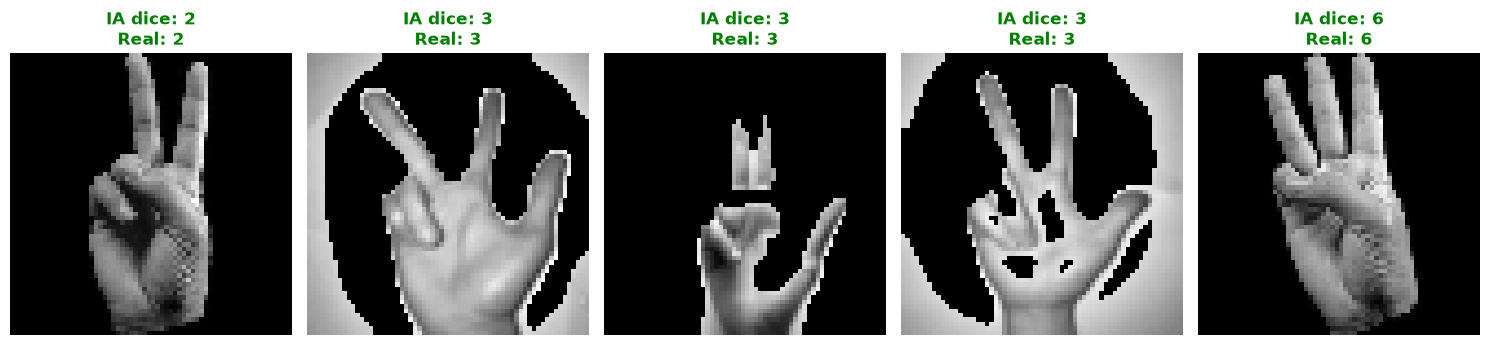

In [12]:

#   PRUEBA VISUAL

# 5 números de lista al azar del grupo de prueba
indices_al_azar = np.random.choice(len(X_test), 5, replace=False)

plt.figure(figsize=(15, 4))

for i, idx in enumerate(indices_al_azar):
    
    foto_pregunta = X_test[idx]
    respuesta_real = np.argmax(y_test[idx]) 
    

    foto_empaquetada = np.expand_dims(foto_pregunta, axis=0) 
    prediccion_ia = model.predict(foto_empaquetada, verbose=0)
    respuesta_ia = np.argmax(prediccion_ia) 
    
    # Dibujo de los resultados
    plt.subplot(1, 5, i + 1)

    plt.imshow(foto_pregunta.reshape(64, 64), cmap='gray') 
    
    # verde correcto, rojo fallado
    color_texto = 'green' if respuesta_real == respuesta_ia else 'red'
    
    plt.title(f"IA dice: {respuesta_ia}\nReal: {respuesta_real}", color=color_texto, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Cargar la extensión de TensorBoard en el Notebook
%load_ext tensorboard

# Abrir el panel interactivo leyendo la carpeta de logs
%tensorboard --logdir logs/fit

In [14]:

# PRUEBA FINAL CON DATOS NUNCA ANTES VISTOS

print("Evaluando el modelo definitivo con el set de Prueba (Test)...")


test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"\\nPrecisión final en datos de prueba: {test_acc * 100:.2f}%")
print(f"Pérdida final en datos de prueba: {test_loss:.4f}")

Evaluando el modelo definitivo con el set de Prueba (Test)...
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9646 - loss: 0.1998
\nPrecisión final en datos de prueba: 96.46%
Pérdida final en datos de prueba: 0.1998


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar tu foto
nombre_foto = 'prueba3.jpg'
img = cv2.imread(nombre_foto, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: No pude encontrar '{nombre_foto}'")
else:
    # --- Recorte Cuadrado ---
    h, w = img.shape
    min_dim = min(h, w)
    start_x = w//2 - min_dim//2
    start_y = h//2 - min_dim//2
    img_cropped = img[start_y:start_y+min_dim, start_x:start_x+min_dim]
    
    # ==========================================
    # EL TRUCO MEJORADO: LA MÁSCARA (GREEN SCREEN)
    # ==========================================
    img_blur = cv2.GaussianBlur(img_cropped, (7, 7), 0)
    
    # 1. Creamos la silueta (blanco para la mano, negro para la pared)
    _, mascara = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # 2. Magia: Pegamos la textura ORIGINAL de tu mano sobre el fondo negro de la máscara
    img_filtrada = cv2.bitwise_and(img_cropped, img_cropped, mask=mascara)
    # ==========================================
    
    # Redimensionar a 64x64 y preparar el tensor
    img_resized = cv2.resize(img_filtrada, (64, 64))
    img_normalized = img_resized.astype('float32') / 255.0
    img_tensor = img_normalized.reshape(1, 64, 64, 1)

    # Predicción
    predicciones = model.predict(img_tensor)
    numero_ganador = np.argmax(predicciones)
    confianza = np.max(predicciones) * 100

    # 4. Mostrar la magia visual
    plt.figure(figsize=(10, 5))
    
    # Foto tuya con el recorte perfecto
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Lo que ve la IA AHORA\nPredicción: {numero_ganador} (Confianza: {confianza:.1f}%)", 
              fontsize=12, fontweight='bold', color='darkgreen')
    plt.axis('off')
    
    # Foto de ejemplo del dataset de entrenamiento para comparar
    plt.subplot(1, 2, 2)
    plt.imshow(X_train[0].reshape(64,64), cmap='gray') 
    plt.title("El 'ADN' que la IA esperaba ver\n(Foto de tu Dataset)", fontsize=12)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("\n=== NUEVAS PROBABILIDADES ===")
    for i, prob in enumerate(predicciones[0]):
        print(f"Número {i}: {prob*100:.5f}%")



In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar tu foto (Asegúrate de que sea la misma de tu pared clara)
nombre_foto = 'prueba.jpg'
img = cv2.imread(nombre_foto, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: No pude encontrar '{nombre_foto}'")
else:
    # --- Recorte Cuadrado ---
    h, w = img.shape
    min_dim = min(h, w)
    start_x = w//2 - min_dim//2
    start_y = h//2 - min_dim//2
    img_cropped = img[start_y:start_y+min_dim, start_x:start_x+min_dim]
    
    # ==========================================
    # EL TRUCO DE OPENCV: FILTRO DE ADAPTACIÓN
    # ==========================================
    # 1. Aplicamos un pequeño desenfoque para eliminar el "ruido" de la cámara
    img_blur = cv2.GaussianBlur(img_cropped, (7, 7), 0)
    
    # 2. Binarización de Otsu Invertida
    # Como tu pared es más clara que tu mano, esto volverá la pared NEGRA y tu mano BLANCA
    _, img_filtrada = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # ==========================================
    
    # Redimensionar a 64x64 y preparar el tensor
    img_resized = cv2.resize(img_filtrada, (64, 64))
    img_normalized = img_resized.astype('float32') / 255.0
    img_tensor = img_normalized.reshape(1, 64, 64, 1)

    # Predicción
    predicciones = model.predict(img_tensor)
    numero_ganador = np.argmax(predicciones)
    confianza = np.max(predicciones) * 100

    # 4. Mostrar la magia visual
    plt.figure(figsize=(10, 5))
    
    # Foto tuya con el filtro puesto
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized, cmap='gray')
    plt.title(f"Lo que ve la IA AHORA\nPredicción: {numero_ganador} (Confianza: {confianza:.1f}%)", 
              fontsize=12, fontweight='bold', color='darkgreen')
    plt.axis('off')
    
    # Foto de ejemplo del dataset de entrenamiento para comparar
    plt.subplot(1, 2, 2)
    # Tomamos la primera imagen del set de entrenamiento para comparar
    plt.imshow(X_train[0].reshape(64,64), cmap='gray') 
    plt.title("El 'ADN' que la IA esperaba ver\n(Foto de tu Dataset)", fontsize=12)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("\n=== NUEVAS PROBABILIDADES ===")
    for i, prob in enumerate(predicciones[0]):
        print(f"Número {i}: {prob*100:.5f}%")

In [17]:

# Guardado
model.save('modelov3.keras')
print("modelo guardado")

modelo guardado


Analizando el set de prueba en busca de errores...
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Total de imágenes evaluadas: 707
Total de equivocaciones: 25

--------------------------------------------------
GALERÍA DE ERRORES:


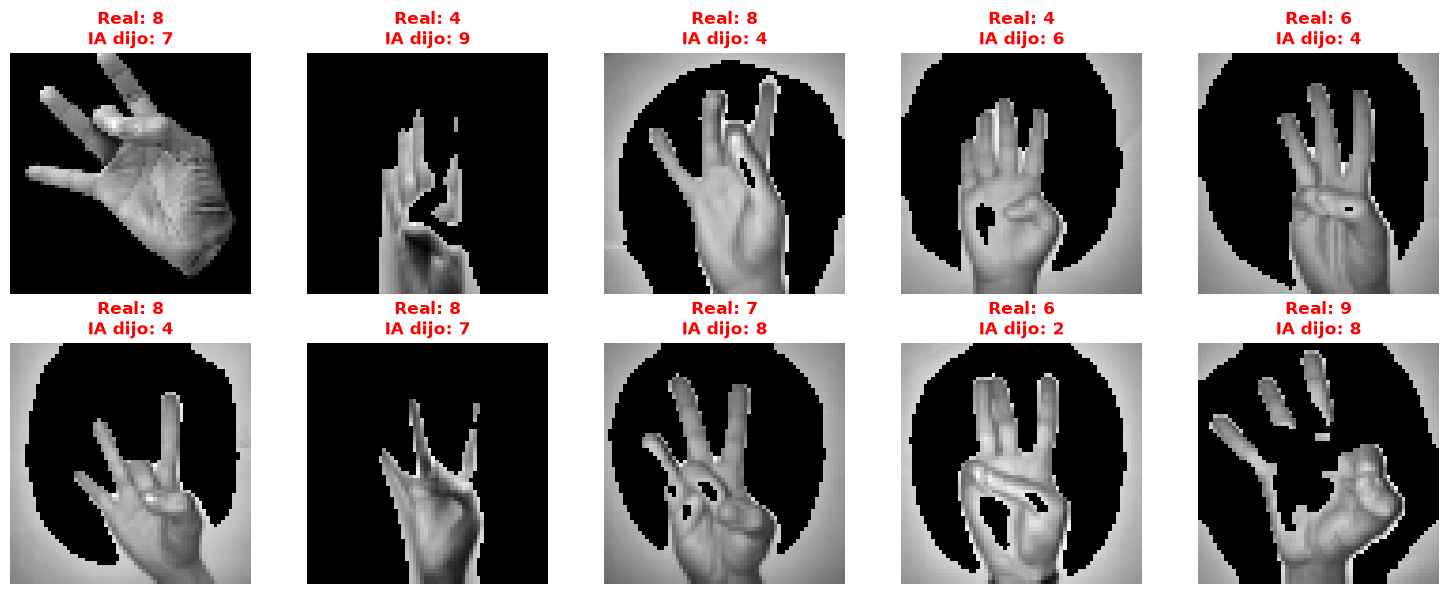

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Hacemos que la IA adivine TODAS las imágenes del set de prueba de una sola vez
print("Analizando el set de prueba en busca de errores...")
predicciones_test = model.predict(X_test)

# 2. Convertimos el formato One-Hot (Ej: [0,0,1...]) a números normales (Ej: 2)
etiquetas_reales = np.argmax(y_test, axis=1)
etiquetas_predichas = np.argmax(predicciones_test, axis=1)

# 3. Magia de NumPy: Comparamos las dos listas y guardamos dónde son diferentes
errores_indices = np.where(etiquetas_reales != etiquetas_predichas)[0]

print(f"Total de imágenes evaluadas: {len(X_test)}")
print(f"Total de equivocaciones: {len(errores_indices)}")

# 4. Mostrar una grilla con los errores (Máximo 10 para no saturar tu pantalla)
if len(errores_indices) > 0:
    print(f"\n{50 * '-'}\nGALERÍA DE ERRORES:")
    
    # Calculamos cuántas mostrar (10 o menos)
    cantidad_a_mostrar = min(10, len(errores_indices))
    
    plt.figure(figsize=(15, 6))
    
    for i in range(cantidad_a_mostrar):
        idx = errores_indices[i] # Sacamos el índice de la imagen que falló
        
        plt.subplot(2, 5, i + 1)
        # Volvemos a darle forma 64x64 para poder imprimirla en pantalla
        plt.imshow(X_test[idx].reshape(64, 64), cmap='gray')
        
        # Título en rojo mostrando qué número era y qué creyó la IA
        plt.title(f"Real: {etiquetas_reales[idx]}\nIA dijo: {etiquetas_predichas[idx]}", 
                  color='red', fontweight='bold')
        plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("¡Impresionante! El modelo no tuvo ni un solo fallo en este lote.")

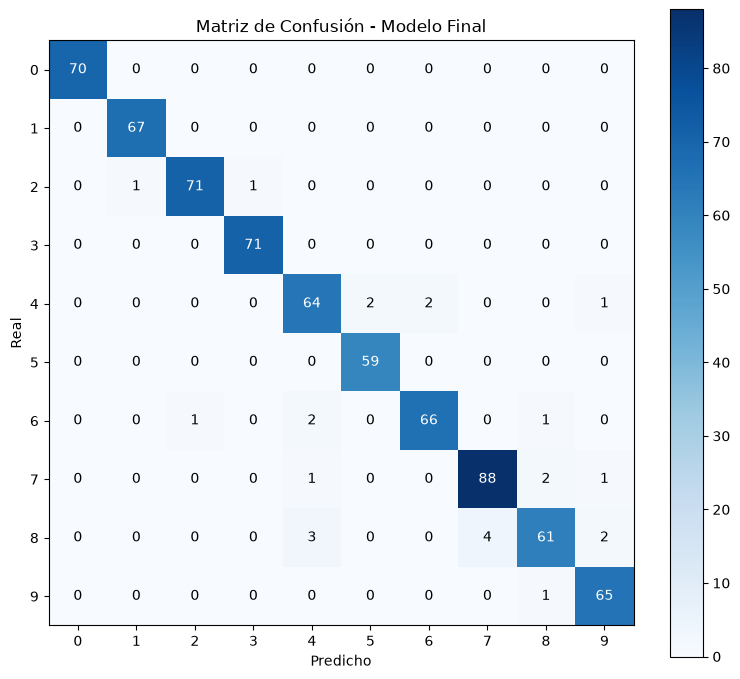

Clase Accuracy  Confundido con
0     1.000     {}
1     1.000     {}
2     0.973     {np.int64(1): np.int64(1), np.int64(3): np.int64(1)}
3     1.000     {}
4     0.928     {np.int64(5): np.int64(2), np.int64(6): np.int64(2), np.int64(9): np.int64(1)}
5     1.000     {}
6     0.943     {np.int64(2): np.int64(1), np.int64(4): np.int64(2), np.int64(8): np.int64(1)}
7     0.957     {np.int64(4): np.int64(1), np.int64(8): np.int64(2), np.int64(9): np.int64(1)}
8     0.871     {np.int64(4): np.int64(3), np.int64(7): np.int64(4), np.int64(9): np.int64(2)}
9     0.985     {np.int64(8): np.int64(1)}


In [19]:
# Agregar como celda nueva DESPUÉS de la celda de entrenamiento (celda 10),
# usando las mismas variables X_test, y_test que ya tienes en el notebook.

import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

pred = model.predict(X_test, verbose=0)
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(y_true, y_pred)

# Heatmap para el informe
plt.figure(figsize=(8,7))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.title('Matriz de Confusión - Modelo Final')
for i in range(10):
    for j in range(10):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        plt.text(j, i, cm[i,j], ha='center', va='center', color=color)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150)
plt.show()

# Detalle por clase, para identificar rápido cuáles son las clases problema
print(f"{'Clase':<6}{'Accuracy':<10}{'Confundido con'}")
for i in range(10):
    idx = y_true == i
    acc = (y_pred[idx] == i).mean()
    errores = y_pred[idx][y_pred[idx] != i]
    confusiones = dict(zip(*np.unique(errores, return_counts=True))) if len(errores) else {}
    print(f"{i:<6}{acc:<10.3f}{confusiones}")